In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, f1_score, 
                              precision_score, recall_score, 
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import time
warnings.filterwarnings('ignore')

print("Cargando dataset...")
df = pd.read_csv('../datos/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv')
df.columns = df.columns.str.strip()

print(f"Dataset cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas")

# LIMPIEZA
print("\nLimpiando datos...")

# 1. Reemplazar infinitos con NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Eliminar filas con NaN
filas_antes = len(df)
df.dropna(inplace=True)
filas_despues = len(df)
print(f"Filas eliminadas por NaN/Inf: {filas_antes - filas_despues:,}")
print(f"Filas restantes: {filas_despues:,}")

# 3. Separar features y etiquetas
X = df.drop('Label', axis=1)

# Eliminar columna Timestamp si existe
if 'Timestamp' in X.columns:
    X = X.drop('Timestamp', axis=1)

y = df['Label']

# 4. Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\nClases: {list(le.classes_)}")
print(f"Codificación: Benign={le.transform(['Benign'])[0]}, Bot={le.transform(['Bot'])[0]}")
print(f"\nFeatures para entrenamiento: {X.shape[1]}")
print("Preprocesamiento completado ✓")

Cargando dataset...
Dataset cargado: 1,048,575 filas, 80 columnas

Limpiando datos...
Filas eliminadas por NaN/Inf: 4,050
Filas restantes: 1,044,525

Clases: ['Benign', 'Bot']
Codificación: Benign=0, Bot=1

Features para entrenamiento: 78
Preprocesamiento completado ✓


In [2]:
print("Dividiendo datos: 80% entrenamiento, 20% prueba...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Mantiene proporción de clases
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas")
print(f"Prueba:        {X_test.shape[0]:,} filas")
print(f"\nDistribución en entrenamiento:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c:,} ({c/len(y_train)*100:.1f}%)")

Dividiendo datos: 80% entrenamiento, 20% prueba...
Entrenamiento: 835,620 filas
Prueba:        208,905 filas

Distribución en entrenamiento:
  Benign: 606,667 (72.6%)
  Bot: 228,953 (27.4%)


In [3]:
print("Entrenando modelo centralizado (Random Forest)...")
print("Esto puede tardar 2-5 minutos, es normal...\n")

inicio = time.time()

modelo_centralizado = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,          # Usa todos los núcleos de tu Ryzen 5
    class_weight='balanced'
)

modelo_centralizado.fit(X_train, y_train)

tiempo_entrenamiento = time.time() - inicio
print(f"Entrenamiento completado en {tiempo_entrenamiento:.1f} segundos ✓")

Entrenando modelo centralizado (Random Forest)...
Esto puede tardar 2-5 minutos, es normal...

Entrenamiento completado en 43.9 segundos ✓


In [4]:
print("Evaluando modelo centralizado...")
print("=" * 55)

y_pred = modelo_centralizado.predict(X_test)

# Métricas principales
f1 = f1_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print(f"\nMÉTRICAS GLOBALES (macro):")
print(f"  F1-Score:  {f1:.4f}  ({f1*100:.2f}%)")
print(f"  Precisión: {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f}  ({recall*100:.2f}%)")

print(f"\nREPORTE DETALLADO POR CLASE:")
print(classification_report(y_test, y_pred, 
                              target_names=le.classes_))

# Guardar métricas baseline
baseline = {
    'modelo': 'Random Forest Centralizado',
    'n_estimators': 100,
    'f1_macro': round(f1, 4),
    'precision_macro': round(precision, 4),
    'recall_macro': round(recall, 4),
    'tiempo_entrenamiento_seg': round(tiempo_entrenamiento, 1),
    'filas_entrenamiento': int(X_train.shape[0]),
    'filas_prueba': int(X_test.shape[0]),
    'features': int(X.shape[1])
}

with open('../resultados/baseline_centralizado.json', 'w') as f:
    json.dump(baseline, f, indent=2)

print(f"\nBaseline guardado en resultados/baseline_centralizado.json")
print(f"\nEste F1-Score de {f1:.4f} es tu PUNTO DE REFERENCIA.")
print(f"El modelo federado debe alcanzar al menos el 85% de este valor.")
print(f"85% del baseline = F1 >= {f1 * 0.85:.4f}")

Evaluando modelo centralizado...

MÉTRICAS GLOBALES (macro):
  F1-Score:  1.0000  (100.00%)
  Precisión: 1.0000  (100.00%)
  Recall:    1.0000  (100.00%)

REPORTE DETALLADO POR CLASE:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    151667
         Bot       1.00      1.00      1.00     57238

    accuracy                           1.00    208905
   macro avg       1.00      1.00      1.00    208905
weighted avg       1.00      1.00      1.00    208905


Baseline guardado en resultados/baseline_centralizado.json

Este F1-Score de 1.0000 es tu PUNTO DE REFERENCIA.
El modelo federado debe alcanzar al menos el 85% de este valor.
85% del baseline = F1 >= 0.8500


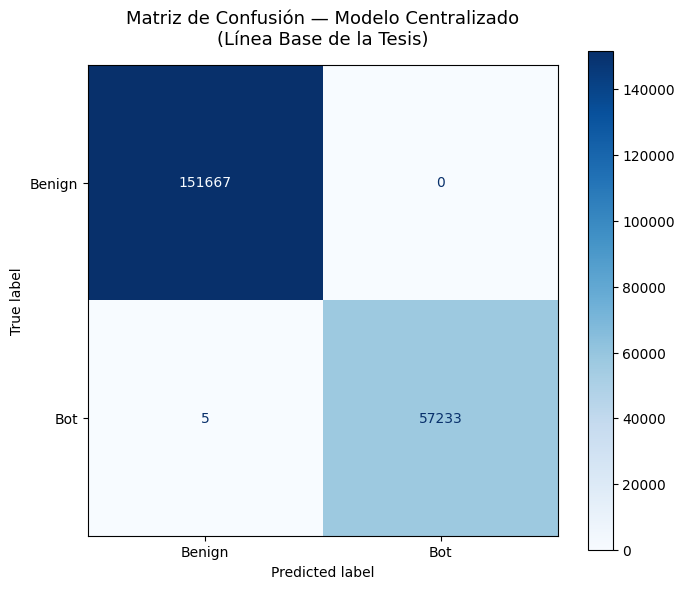

Gráfico guardado ✓


In [5]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('Matriz de Confusión — Modelo Centralizado\n(Línea Base de la Tesis)', 
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../resultados/confusion_matrix_centralizado.png', dpi=150)
plt.show()
print("Gráfico guardado ✓")

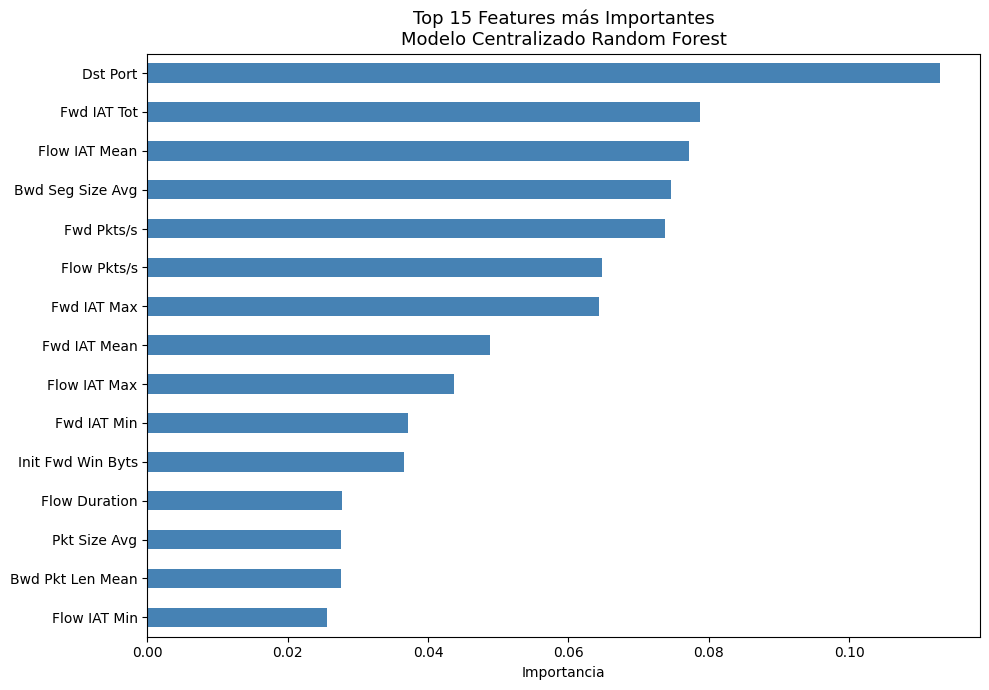

Top 5 features más importantes:
  Dst Port: 0.1130
  Fwd IAT Tot: 0.0787
  Flow IAT Mean: 0.0772
  Bwd Seg Size Avg: 0.0746
  Fwd Pkts/s: 0.0737


In [6]:
# Top 15 features más importantes para el modelo
importancias = pd.Series(
    modelo_centralizado.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
importancias.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Features más Importantes\nModelo Centralizado Random Forest', 
             fontsize=13)
ax.set_xlabel('Importancia')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../resultados/feature_importance_centralizado.png', dpi=150)
plt.show()

print("Top 5 features más importantes:")
for feat, imp in importancias.head(5).items():
    print(f"  {feat}: {imp:.4f}")

In [7]:
import subprocess

comandos = [
    ['git', 'add', '.'],
    ['git', 'commit', '-m', 
     f'feat: modelo centralizado baseline F1={f1:.4f} tiempo={tiempo_entrenamiento:.0f}s'],
    ['git', 'push']
]

for cmd in comandos:
    resultado = subprocess.run(cmd, cwd='C:/tesis-fl-ids', 
                               capture_output=True, text=True)
    if resultado.returncode == 0:
        print(f"✓ {' '.join(cmd[1:3])}")
    else:
        print(f"✗ Error: {resultado.stderr[:100]}")

print("\nModelo centralizado completado y guardado en GitHub ✓")

✓ add .
✓ commit -m
✗ Error: remote: error: Trace: 452a2c5a51c018d06f76d8c4b8699f6c082779105925a1f15bbecce1bd5cacd3        
remot

Modelo centralizado completado y guardado en GitHub ✓
